<a href="https://colab.research.google.com/github/paulclarkdata/periodic_table_cluster/blob/main/period_table_cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 1: Setup

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/andrejewski/periodic-table/master/data.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.columns.tolist())
df.head(10)

(118, 20)
['atomicNumber', ' symbol', ' name', ' atomicMass', ' cpkHexColor', ' electronicConfiguration', ' electronegativity', ' atomicRadius', ' ionRadius', ' vanDelWaalsRadius', ' ionizationEnergy', ' electronAffinity', ' oxidationStates', ' standardState', ' bondingType', ' meltingPoint', ' boilingPoint', 'density', ' groupBlock', ' yearDiscovered']


,atomicNumber,symbol,name,atomicMass,cpkHexColor,electronicConfiguration,electronegativity,atomicRadius,ionRadius,vanDelWaalsRadius,ionizationEnergy,electronAffinity,oxidationStates,standardState,bondingType,meltingPoint,boilingPoint,density,groupBlock,yearDiscovered
0,1,H,Hydrogen,1.00794(4),FFFFFF,1s1,2.20,37.0,NaN,120.0,1312.0,-73.0,"-1, 1",gas,diatomic,14.0,20.0,0.000090,nonmetal,1766
1,2,He,Helium,4.002602(2),D9FFFF,1s2,NaN,32.0,NaN,140.0,2372.0,0.0,NaN,gas,atomic,NaN,4.0,0.000179,noble gas,1868
2,3,Li,Lithium,6.941(2),CC80FF,[He] 2s1,0.98,134.0,76 (+1),182.0,520.0,-60.0,1,solid,metallic,454.0,1615.0,0.535000,alkali metal,1817
3,4,Be,Beryllium,9.012182(3),C2FF00,[He] 2s2,1.57,90.0,45 (+2),NaN,900.0,0.0,2,solid,metallic,1560.0,2743.0,1.848000,alkaline earth metal,1798
4,5,B,Boron,10.811(7),FFB5B5,[He] 2s2 2p1,2.04,82.0,27 (+3),NaN,801.0,-27.0,"1, 2, 3",solid,covalent network,2348.0,4273.0,2.460000,metalloid,1807
5,6,C,Carbon,12.0107(8),909090,[He] 2s2 2p2,2.55,77.0,16 (+4),170.0,1087.0,-154.0,"-4, -3, -2, -1, 1, 2, 3, 4",solid,covalent network,3823.0,4300.0,2.260000,nonmetal,Ancient
6,7,N,Nitrogen,14.0067(2),3050F8,[He] 2s2 2p3,3.04,75.0,146 (-3),155.0,1402.0,-7.0,"-3, -2, -1, 1, 2, 3, 4, 5",gas,diatomic,63.0,77.0,0.001251,nonmetal,1772
7,8,O,Oxygen,15.9994(3),FF0D0D,[He] 2s2 2p4,3.44,73.0,140 (-2),152.0,1314.0,-141.0,"-2, -1, 1, 2",gas,diatomic,55.0,90.0,0.001429,nonmetal,1774
8,9,F,Fluorine,18.9984032(5),90E050,[He] 2s2 2p5,3.98,71.0,133 (-1),147.0,1681.0,-328.0,-1,gas,atomic,54.0,85.0,0.001696,halogen,1670
9,10,Ne,Neon,20.1797(6),B3E3F5,[He] 2s2 2p6,NaN,69.0,NaN,154.0,2081.0,0.0,NaN,gas,atomic,25.0,27.0,0.000900,noble gas,1898


In [2]:
df.to_csv('elements_raw.csv', index=False)

## Phase 2: EDA ##

In [3]:
# Check for null values in the dataset
df.isnull().sum()

,0
atomicNumber,0
symbol,0
name,0
atomicMass,0
cpkHexColor,9
electronicConfiguration,0
electronegativity,21
atomicRadius,47
ionRadius,26
vanDelWaalsRadius,80


The superheavy elements have null values for all numeric columns

vanDelWaalsRadius has the most missing values (80/118 elements) - will evaluate whether to retain or drop during feature selection

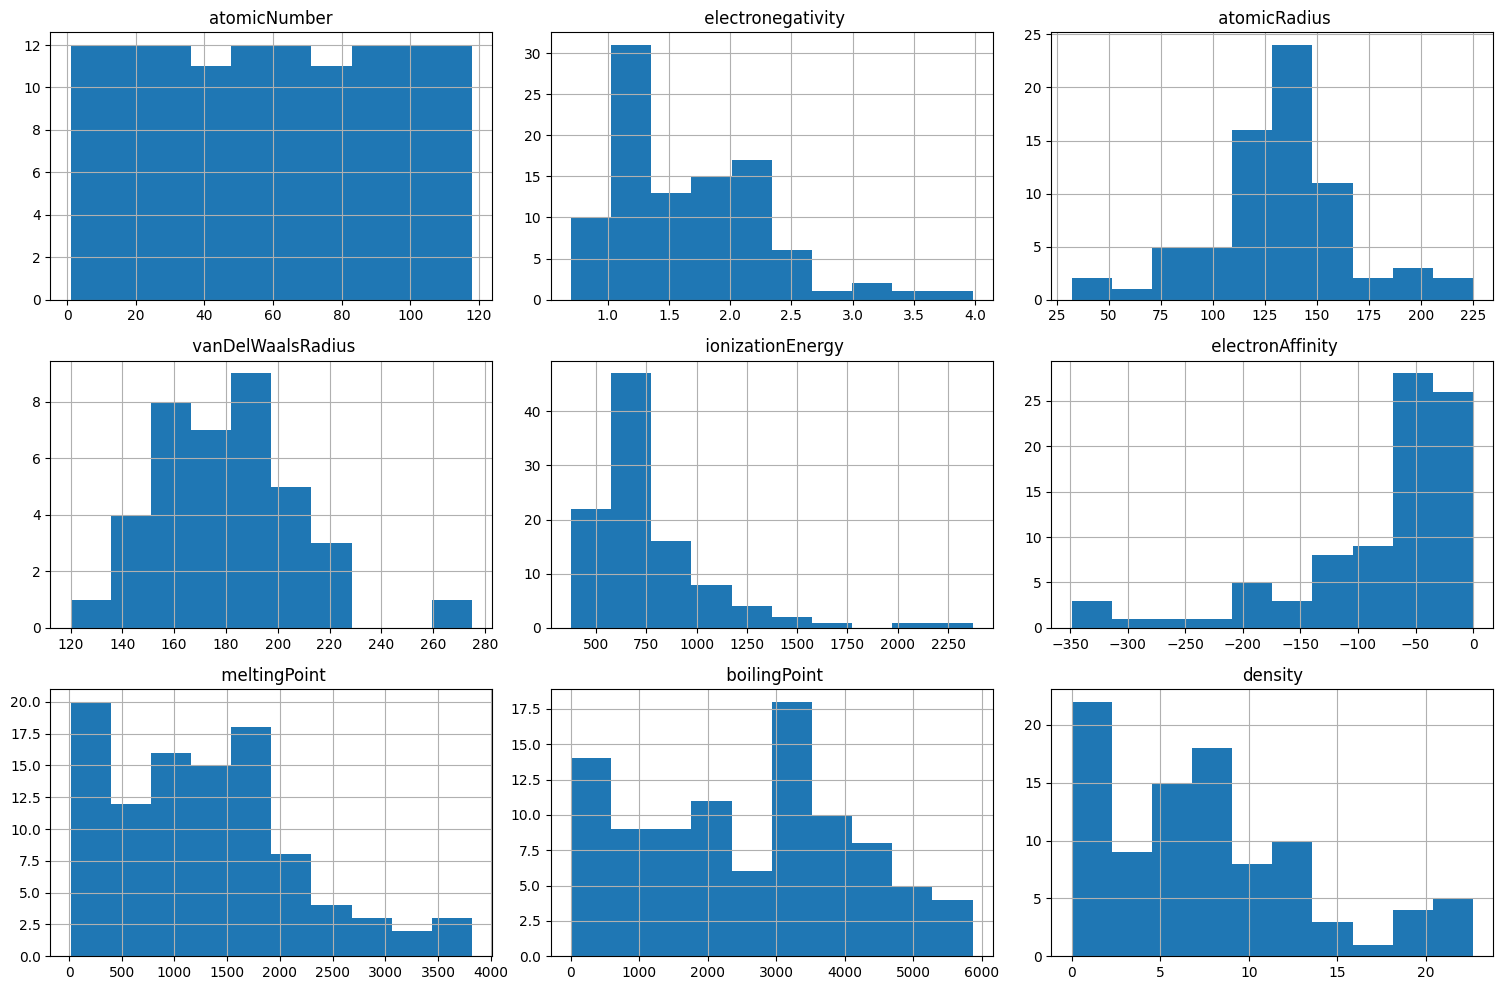

In [4]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

ionizationEnergy is skewed right


electronAffinity is skewed left

vanDelWaalsRadius has an outlier around 270

Feature scaling: the process of converting all numeric columns to the same scale so they can be fairly compared.

The skewed distributions and outliers show the need for feature scaling before applying k-means, which is sensitive to differences in magnitude.

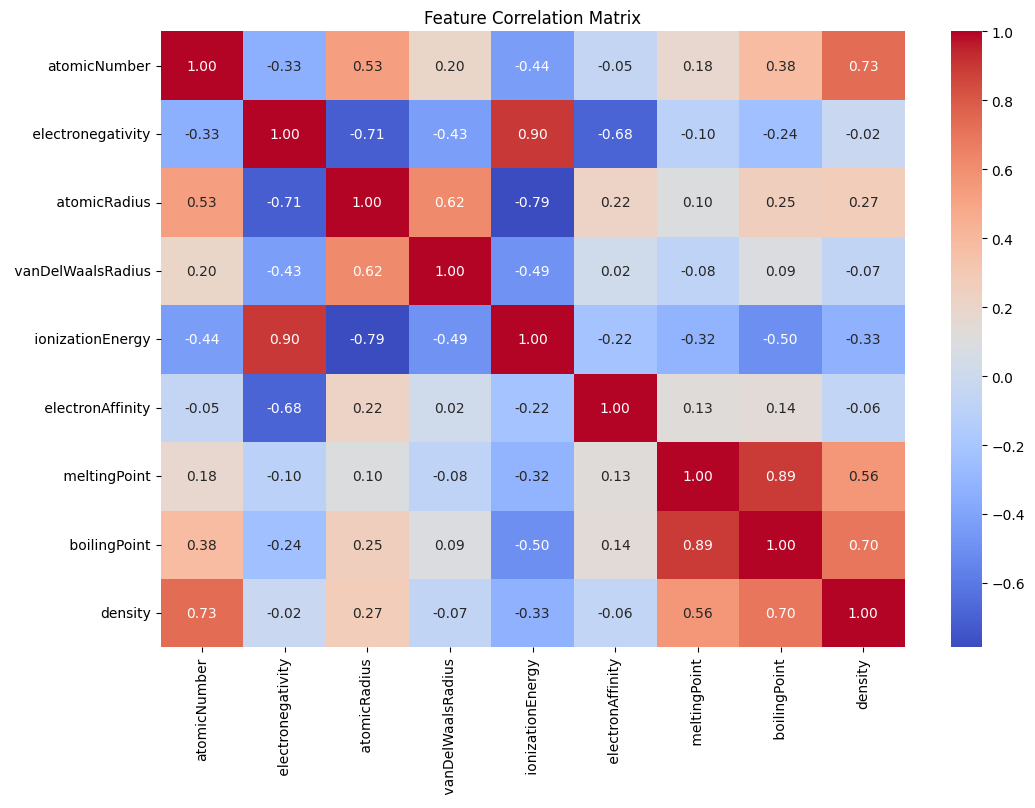

In [5]:
import seaborn as sns

corr_matrix = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

* ionizationEnergy and electronegativity have a very high positive correlation at .90
* meltingPoint and boilingPoint have a very high positive correlation at .89


## Phase 3: Feature Selection ##

* Feature Selection: taking the raw 20 column dataframe and producing a clean analysis ready dataframe
* Decided to keep electronegativity instead of ionizationEnergy as I believe it tells a better story about the element's chemical character
* Decided to keep meltingPoint instead of boilingPoint as I believe it tells a better story about the element's chemical character


**Features to Keep or not Keep**

* atomicNumber: Dropped because this is an identifier
* symbol: Dropped because this is an identifier
* name: Dropped because this is an identifier
* atomicMass: Dropped because this is redundant with atomic number
* cpkHexColor: Dropped because this is an identifier
* electronicConfiguration: Dropped because this is a text column
* electronegativity: Keep
* atomicRadius: Keep
* ionRadius: Keep
* vanDelWaalsRadius: Keep
* ionizationEnergy: Dropped due to high correlation with electronegativity
* electronAffinity: Keep
* oxidationStates: Dropped because this is a string
* standardState: Dropped because this is a text column
* bondingType: Dropped because this is a text column
* meltingPoint: Keep
* boilingPoint: Dropped due to high correlation with meltingPoint
* density: Keep
* groupBlock: Dropped because this is a text column
* yearDiscovered: Dropped because this is an identifier

In [11]:
# Create the clean analytics ready dataframe
dataframe_clean = df[[' electronegativity', ' atomicRadius', ' ionRadius', ' vanDelWaalsRadius', ' ionizationEnergy', ' electronAffinity', ' meltingPoint', 'density']]

In [15]:
dataframe_clean.shape
dataframe_clean.head()

,electronegativity,atomicRadius,ionRadius,vanDelWaalsRadius,ionizationEnergy,electronAffinity,meltingPoint,density
0,2.20,37.0,NaN,120.0,1312.0,-73.0,14.0,0.000090
1,NaN,32.0,NaN,140.0,2372.0,0.0,NaN,0.000179
2,0.98,134.0,76 (+1),182.0,520.0,-60.0,454.0,0.535000
3,1.57,90.0,45 (+2),NaN,900.0,0.0,1560.0,1.848000
4,2.04,82.0,27 (+3),NaN,801.0,-27.0,2348.0,2.460000
